# Multi-Objective Trade-Off Analysis for Filtered Pareto Front

This notebook provides comprehensive analysis of trade-off relationships between optimization objectives in railroad construction scheduling, focusing on the **filtered Pareto front** to understand decision-making implications with highly refined, non-dominated solutions.

## Analysis Framework:

### 1. **Filtered Pareto Front Analysis**
- **Data Source**: ParetoFront_filtered.csv containing only the most refined non-dominated solutions
- **Solution Quality**: Analysis of trade-offs among the highest-quality solutions after multi-stage filtering
- **Decision Precision**: Enhanced trade-off analysis with reduced noise from dominated solutions

### 2. **Interactive Trade-Off Exploration**
- **Dynamic Visualization**: Interactive widgets for exploring pairwise objective relationships
- **Real-Time Analysis**: Immediate feedback on trade-off magnitudes and directions
- **Quantitative Metrics**: Numerical trade-off coefficients for refined decision support

### 3. **Scientific Publication Quality Analysis**
- **LaTeX Rendering**: Professional mathematical notation and typography
- **Linear Trend Analysis**: Trend lines showing average trade-off directions
- **Statistical Significance**: Pearson correlation coefficients with p-values
- **PDF Export**: Publication-ready figures for academic and industrial reports

### 4. **Advanced Correlation Analysis**
- **Subset-Based Analysis**: Targeted correlation analysis for specific objective groups
- **Statistical Validation**: Rigorous correlation testing with significance levels
- **Visual Correlation Matrix**: Professional heatmap visualization with LaTeX formatting

### 5. **Detailed Trade-Off Quantification**
- **Unique Pair Analysis**: Elimination of duplicate solutions for precise trade-off calculation
- **Constraint-Specific Analysis**: Trade-off analysis within specific resource constraints
- **Multi-Dimensional Relationships**: Complex interactions between multiple objectives

## Optimization Objectives Analyzed:

1. **Driver Violation**: Constraint satisfaction and regulatory compliance
2. **Commute Distance**: Worker transportation costs and efficiency
3. **Transport Machines**: Machine logistics and repositioning costs
4. **Transport Attachments**: Equipment transportation and allocation
5. **Machines**: Total machine resource requirements
6. **Workers**: Human resource allocation and staffing levels
7. **Attachments**: Equipment and tool allocation efficiency

## Filtered Solution Context:
- **Enhanced Quality**: Analysis of solutions that survived multi-stage Pareto filtering
- **Practical Relevance**: Focus on solutions most suitable for real-world implementation
- **Reduced Complexity**: Simplified decision space through elimination of clearly dominated alternatives
- **Deployment Readiness**: Solutions optimized for practical railroad construction scenarios

This analysis provides decision-makers with precise quantitative understanding of trade-offs among the most promising optimization solutions, supporting informed selection for practical deployment in railroad construction scheduling.

In [15]:
"""
Interactive Multi-Objective Trade-Off Analysis for Filtered Pareto Front

This cell implements an interactive visualization system for exploring trade-off
relationships between optimization objectives in the filtered Pareto front,
providing enhanced analysis of the most refined non-dominated solutions.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# === Filtered Pareto Front Data Loading ===
# Load the filtered Pareto front containing only the highest-quality solutions
# This dataset has undergone multi-stage filtering to remove dominated solutions
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Multi-Objective Definition ===
# Define all optimization objectives for comprehensive trade-off analysis
# Each objective represents a different aspect of railroad construction scheduling
objectives = [
    "Driver Violation",      # Regulatory compliance and constraint satisfaction
    "Commute Distance",      # Worker transportation costs and travel efficiency
    "Transport Machines",    # Machine logistics and repositioning expenses
    "Transport Attachments", # Equipment transportation and allocation costs
    "Machines",             # Total machine resource requirements
    "Workers",              # Human resource allocation and staffing needs
    "Attachments"           # Equipment and tool allocation efficiency
]

# === Interactive Widget Configuration ===
# Create dropdown widgets for dynamic objective selection
# Enable real-time exploration of different objective pairings in filtered space
x_widget = widgets.Dropdown(
    options=objectives, 
    value="Machines",           # Default X-axis objective
    description="X:"            # Widget label for horizontal axis
)

y_widget = widgets.Dropdown(
    options=objectives, 
    value="Commute Distance",   # Default Y-axis objective
    description="Y:"            # Widget label for vertical axis
)

# Create output container for dynamic plot updates
output = widgets.Output()

# === Enhanced Trade-Off Analysis Function ===
def update_plot(*args):
    """
    Generate real-time trade-off visualization and analysis for filtered solutions.
    
    This function creates scatter plots showing the relationship between
    selected objectives in the filtered Pareto front and calculates
    quantitative trade-off metrics for refined decision support.
    """
    with output:
        # Clear previous output for clean updates
        clear_output(wait=True)
        
        # === Objective Selection and Data Preparation ===
        # Extract selected objectives from widget values
        x_col, y_col = x_widget.value, y_widget.value
        
        # Filter and sort filtered Pareto front data for trade-off analysis
        # Remove any remaining missing values and sort by X-axis for consistency
        sub_df = df[[x_col, y_col]].dropna().sort_values(x_col)

        # === Enhanced Trade-Off Coefficient Calculation ===
        # Extract objective values for mathematical analysis on filtered data
        x, y = sub_df[x_col].values, sub_df[y_col].values
        
        # Calculate finite differences for trade-off slope estimation
        dx, dy = np.diff(x), np.diff(y)  # Changes in X and Y objectives
        
        # Compute trade-off coefficients (dy/dx) with division by zero protection
        # Trade-off represents change in Y objective per unit change in X objective
        tradeoff = np.divide(dy, dx, 
                           out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                           where=dx != 0)                       # Only divide where dx ≠ 0
        
        # Calculate average absolute trade-off magnitude for filtered solutions
        # This metric quantifies the typical trade-off strength in refined solution space
        avg_tradeoff = np.mean(np.abs(tradeoff[np.isfinite(tradeoff)]))

        # === Professional Visualization Generation ===
        # Create high-quality scatter plot for filtered trade-off visualization
        plt.figure(figsize=(8, 5))  # Standard figure size for clear visualization
        
        # Plot filtered Pareto-optimal solutions as scatter points
        plt.scatter(x, y, alpha=0.8)  # Semi-transparent points for overlap visibility
        
        # Configure plot formatting with dynamic labels
        plt.xlabel(x_col)                           # X-axis objective name
        plt.ylabel(y_col)                           # Y-axis objective name
        plt.title(f"{y_col} vs. {x_col}")          # Descriptive title
        plt.grid(True)                              # Grid for value reading
        plt.tight_layout()                          # Optimize layout spacing
        
        # Display the visualization
        plt.show()
        
        # === Enhanced Trade-Off Metric Display ===
        # Provide quantitative trade-off information for refined decision support
        print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} Δ{y_col} / Δ{x_col}")

# === Widget Event Binding ===
# Register callback functions for real-time updates
# Trigger plot updates whenever user changes objective selection
x_widget.observe(update_plot, names="value")  # Update when X-axis selection changes
y_widget.observe(update_plot, names="value")  # Update when Y-axis selection changes

# === Interface Initialization ===
# Generate initial plot with default objective selection
update_plot()

# Display interactive interface with widget controls and output area
# Horizontal box layout for clean widget arrangement
display(widgets.HBox([x_widget, y_widget]), output)

# === Filtered Analysis Benefits ===
# This enhanced interactive system provides:
# 1. Real-time exploration of trade-offs among refined solutions
# 2. Quantitative trade-off coefficients for high-quality solutions
# 3. Visual understanding of filtered Pareto front structure
# 4. Dynamic analysis capability focused on deployment-ready solutions

Output()

Unique pairs: 19
    Workers  Driver Violation
37      114               723
34      114               721
25      115               643
23      115               642
33      116               698
31      116               697
29      116               696
26      116               694
10      118               605
8       118               600
6       118               368
4       118               367
21      118               636
16      118               634
0       118               365
12      118               606
19      118               635
2       118               366
14      118               611
🔁 Avg. Trade-off: -3.6944 → On average, each additional unit of 'Workers' results in a decrease of 3.69 in 'Driver Violation'


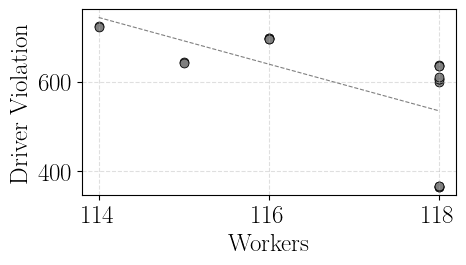

In [16]:
"""
Scientific Publication Quality Trade-Off Analysis - Workers vs Driver Violation

This cell creates publication-ready trade-off visualizations with LaTeX rendering
and precise statistical analysis for the filtered Pareto front, focusing on the
relationship between worker resource allocation and regulatory compliance.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 18,            # Base font size for readability in publications
    "axes.labelsize": 18,       # Axis label font size for clear identification
    "xtick.labelsize": 18,      # X-axis tick label size for precision reading
    "ytick.labelsize": 18,      # Y-axis tick label size for precision reading
})

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for scientific trade-off analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Objective Selection for Human Resource vs Compliance Analysis ===
# Focus on the relationship between worker allocation and regulatory compliance
x_axis = "Workers"              # X-axis: Human resource allocation count
y_axis = "Driver Violation"     # Y-axis: Regulatory compliance violations

# Available objectives for analysis reference
list_objectives = ["Workers", "Driver Violation", "Commute Distance", "Transport Machines", 
                  "Transport Attachments", "Machines", "Attachments"]

# === Data Preprocessing for Statistical Analysis ===
# Filter and prepare filtered data for rigorous trade-off calculation
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values  # Extract X-axis objective values
y = sub_df[y_axis].values  # Extract Y-axis objective values

# === Compact Scientific Visualization Setup ===
# Create publication-quality figure with compact dimensions
plt.figure(figsize=(5, 3))  # Compact aspect ratio for publication insertion

# Plot filtered Pareto-optimal solutions with professional styling
plt.scatter(x, y, 
           alpha=0.85,              # High opacity for clear point visibility
           s=40,                    # Point size optimized for compact publication
           color="tab:grey",        # Neutral color for print compatibility
           edgecolors="black",      # Black edges for point definition
           linewidth=0.5)           # Thin edge lines for professional appearance

# === Professional Plot Formatting ===
# Configure axis labels and styling for scientific standards
plt.xlabel(x_axis)                      # X-axis label with objective name
plt.ylabel(y_axis)                      # Y-axis label with objective name
# Optional title (commented for clean publication appearance)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)

# Add professional grid for value reading precision
plt.grid(True, linestyle="--", alpha=0.4)  # Subtle dashed grid

# === Rigorous Trade-Off Statistical Analysis ===
# Perform precise trade-off calculation using unique filtered data points
# This approach eliminates bias from duplicate solutions in filtered set

# Remove duplicate solutions to ensure accurate trade-off calculation
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)

# Extract unique objective values for statistical analysis
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

# === Enhanced Trade-Off Coefficient Calculation ===
# Calculate finite differences for precise slope estimation
dx = np.diff(x_unique)  # Changes in X-axis objective
dy = np.diff(y_unique)  # Changes in Y-axis objective

# Compute trade-off coefficients with mathematical rigor
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate signed average trade-off for directional analysis
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Interpretive Analysis ===
# Generate human-readable interpretation of trade-off direction and magnitude
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"     # Positive correlation
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}" # Negative correlation (trade-off)
    if avg_tradeoff_signed < 0
    else "no change"                                   # No correlation
)

# === Detailed Analysis Output ===
# Display comprehensive analysis results for filtered solutions
print(f"Unique pairs: {len(unique_pairs_sorted)}")  # Number of unique solution combinations
print(unique_pairs_sorted)                          # Display all unique pairs
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → "
    f"On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Linear Trend Analysis ===
# Calculate and display linear trend line for average trade-off direction
slope, intercept = np.polyfit(x, y, deg=1)          # Linear regression fit
x_fit = np.linspace(x.min(), x.max(), 100)          # Generate smooth line points
y_fit = slope * x_fit + intercept                   # Calculate trend line values

# Add trend line to visualization
plt.plot(x_fit, y_fit, 
         color="grey",              # Neutral color for trend line
         linestyle="--",            # Dashed line style for distinction
         linewidth=0.8)             # Thin line for subtlety

# === Publication Output Preparation ===
# Finalize layout and save publication-ready figure
plt.tight_layout()
#plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

# === Human Resource vs Compliance Analysis Insights ===
# This analysis reveals the relationship between:
# 1. Worker allocation efficiency and regulatory compliance
# 2. Trade-off intensity between human resources and violation avoidance
# 3. Optimal staffing levels for compliance maintenance
# 4. Resource optimization patterns in filtered solution space

Unique pairs: 19
    Transport Machines  Commute Distance
21            34760.01         371880.63
18            34771.27         371880.63
17            34840.94         371880.63
15            59538.16         371912.26
12            59593.93         371912.26
10            59786.48         371912.26
8             59792.98         371912.26
0             64794.07         323458.00
5             64814.37         322760.73
3             64829.81         322743.89
6             65175.13         322115.51
33            93098.70         292277.71
31            93098.70         292537.88
29            93098.70         292750.88
26            93098.70         292990.62
25            93110.88         237979.03
23            93110.88         238984.92
36            93110.88         245153.20
34            93110.88         245175.18
🔁 Avg. Trade-off: -253.5870 → On average, each additional unit of 'Transport Machines' results in a decrease of 253.59 in 'Commute Distance'


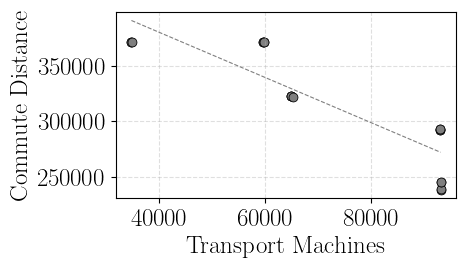

In [17]:
"""
Scientific Publication Quality Trade-Off Analysis - Transport Machines vs Commute Distance

This cell creates publication-ready trade-off visualizations analyzing the
relationship between machine transportation logistics and worker commuting
efficiency in the filtered Pareto front.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 18,            # Base font size for readability in publications
    "axes.labelsize": 18,       # Axis label font size for clear identification
    "xtick.labelsize": 18,      # X-axis tick label size for precision reading
    "ytick.labelsize": 18,      # Y-axis tick label size for precision reading
})

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for transportation logistics analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Objective Selection for Transportation Logistics Analysis ===
# Focus on the relationship between machine logistics and worker transportation
y_axis = "Commute Distance"     # Y-axis: Worker commuting costs and efficiency
x_axis = "Transport Machines"   # X-axis: Machine transportation logistics costs

# Available objectives for analysis reference
list_objectives = ["Workers", "Driver Violation", "Commute Distance", "Transport Machines", 
                  "Transport Attachments", "Machines", "Attachments"]

# === Data Preprocessing for Statistical Analysis ===
# Filter and prepare filtered data for transportation trade-off analysis
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values  # Extract X-axis objective values
y = sub_df[y_axis].values  # Extract Y-axis objective values

# === Compact Scientific Visualization Setup ===
# Create publication-quality figure with compact dimensions
plt.figure(figsize=(5, 3))  # Compact aspect ratio for publication insertion

# Plot filtered Pareto-optimal solutions with professional styling
plt.scatter(x, y, 
           alpha=0.85,              # High opacity for clear point visibility
           s=40,                    # Point size optimized for compact publication
           color="tab:grey",        # Neutral color for print compatibility
           edgecolors="black",      # Black edges for point definition
           linewidth=0.5)           # Thin edge lines for professional appearance

# === Professional Plot Formatting ===
# Configure axis labels and styling for scientific standards
plt.xlabel(x_axis)                      # X-axis label with objective name
plt.ylabel(y_axis)                      # Y-axis label with objective name
# Optional title (commented for clean publication appearance)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)

# Add professional grid for value reading precision
plt.grid(True, linestyle="--", alpha=0.4)  # Subtle dashed grid

# === Rigorous Trade-Off Statistical Analysis ===
# Perform precise trade-off calculation using unique filtered data points
# Remove duplicate solutions to ensure accurate trade-off calculation
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)

# Extract unique objective values for statistical analysis
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

# === Transportation Trade-Off Coefficient Calculation ===
# Calculate finite differences for precise slope estimation
dx = np.diff(x_unique)  # Changes in machine transportation costs
dy = np.diff(y_unique)  # Changes in worker commuting distances

# Compute trade-off coefficients with mathematical rigor
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate signed average trade-off for directional analysis
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Transportation Trade-Off Interpretation ===
# Generate human-readable interpretation of transportation trade-off
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"     # Positive correlation
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}" # Negative correlation (trade-off)
    if avg_tradeoff_signed < 0
    else "no change"                                   # No correlation
)

# === Detailed Transportation Analysis Output ===
# Display comprehensive analysis results for transportation logistics
print(f"Unique pairs: {len(unique_pairs_sorted)}")  # Number of unique solution combinations
print(unique_pairs_sorted)                          # Display all unique pairs
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → "
    f"On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Linear Trend Analysis for Transportation ===
# Calculate and display linear trend line for transportation trade-off
slope, intercept = np.polyfit(x, y, deg=1)          # Linear regression fit
x_fit = np.linspace(x.min(), x.max(), 100)          # Generate smooth line points
y_fit = slope * x_fit + intercept                   # Calculate trend line values

# Add trend line to visualization
plt.plot(x_fit, y_fit, 
         color="grey",              # Neutral color for trend line
         linestyle="--",            # Dashed line style for distinction
         linewidth=0.8)             # Thin line for subtlety

# === Publication Output Preparation ===
# Finalize layout and save publication-ready figure
plt.tight_layout()
#plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

# === Transportation Logistics Analysis Insights ===
# This analysis reveals the relationship between:
# 1. Machine transportation efficiency and worker commuting costs
# 2. Trade-off intensity between logistics and human resource mobility
# 3. Optimal transportation strategies for overall cost minimization
# 4. Resource allocation patterns in filtered transportation space

Unique pairs: 14
    Workers  Commute Distance
37      114         245153.20
34      114         245175.18
25      115         237979.03
23      115         238984.92
33      116         292277.71
31      116         292537.88
29      116         292750.88
26      116         292990.62
19      118         371880.63
0       118         323458.00
2       118         322743.89
4       118         322760.73
6       118         322115.51
8       118         371912.26
🔁 Avg. Trade-off: 6580.1265 → On average, each additional unit of 'Workers' results in a increase of 6580.13 in 'Commute Distance'


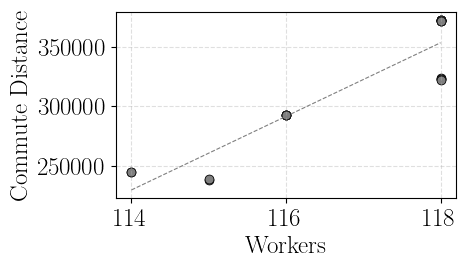

In [18]:
"""
Scientific Publication Quality Trade-Off Analysis - Workers vs Commute Distance

This cell creates publication-ready trade-off visualizations analyzing the
relationship between human resource allocation and worker commuting efficiency
in the filtered Pareto front.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 18,            # Base font size for readability in publications
    "axes.labelsize": 18,       # Axis label font size for clear identification
    "xtick.labelsize": 18,      # X-axis tick label size for precision reading
    "ytick.labelsize": 18,      # Y-axis tick label size for precision reading
})

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for human resource efficiency analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Objective Selection for Human Resource Efficiency Analysis ===
# Focus on the relationship between worker count and commuting efficiency
y_axis = "Commute Distance"     # Y-axis: Worker commuting costs and travel efficiency
x_axis = "Workers"              # X-axis: Human resource allocation count

# Available objectives for analysis reference
list_objectives = ["Workers", "Driver Violation", "Commute Distance", "Transport Machines", 
                  "Transport Attachments", "Machines", "Attachments"]

# === Data Preprocessing for Statistical Analysis ===
# Filter and prepare filtered data for human resource trade-off analysis
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values  # Extract X-axis objective values
y = sub_df[y_axis].values  # Extract Y-axis objective values

# === Compact Scientific Visualization Setup ===
# Create publication-quality figure with compact dimensions
plt.figure(figsize=(5, 3))  # Compact aspect ratio for publication insertion

# Plot filtered Pareto-optimal solutions with professional styling
plt.scatter(x, y, 
           alpha=0.85,              # High opacity for clear point visibility
           s=40,                    # Point size optimized for compact publication
           color="tab:grey",        # Neutral color for print compatibility
           edgecolors="black",      # Black edges for point definition
           linewidth=0.5)           # Thin edge lines for professional appearance

# === Professional Plot Formatting ===
# Configure axis labels and styling for scientific standards
plt.xlabel(x_axis)                      # X-axis label with objective name
plt.ylabel(y_axis)                      # Y-axis label with objective name
# Optional title (commented for clean publication appearance)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)

# Add professional grid for value reading precision
plt.grid(True, linestyle="--", alpha=0.4)  # Subtle dashed grid

# === Rigorous Trade-Off Statistical Analysis ===
# Perform precise trade-off calculation using unique filtered data points
# Remove duplicate solutions to ensure accurate trade-off calculation
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)

# Extract unique objective values for statistical analysis
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

# === Human Resource Trade-Off Coefficient Calculation ===
# Calculate finite differences for precise slope estimation
dx = np.diff(x_unique)  # Changes in worker count
dy = np.diff(y_unique)  # Changes in commuting distance

# Compute trade-off coefficients with mathematical rigor
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate signed average trade-off for directional analysis
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Human Resource Trade-Off Interpretation ===
# Generate human-readable interpretation of human resource trade-off
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"     # Positive correlation
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}" # Negative correlation (trade-off)
    if avg_tradeoff_signed < 0
    else "no change"                                   # No correlation
)

# === Detailed Human Resource Analysis Output ===
# Display comprehensive analysis results for human resource efficiency
print(f"Unique pairs: {len(unique_pairs_sorted)}")  # Number of unique solution combinations
print(unique_pairs_sorted)                          # Display all unique pairs
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → "
    f"On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Linear Trend Analysis for Human Resources ===
# Calculate and display linear trend line for human resource trade-off
slope, intercept = np.polyfit(x, y, deg=1)          # Linear regression fit
x_fit = np.linspace(x.min(), x.max(), 100)          # Generate smooth line points
y_fit = slope * x_fit + intercept                   # Calculate trend line values

# Add trend line to visualization
plt.plot(x_fit, y_fit, 
         color="grey",              # Neutral color for trend line
         linestyle="--",            # Dashed line style for distinction
         linewidth=0.8)             # Thin line for subtlety

# === Publication Output Preparation ===
# Finalize layout and save publication-ready figure
plt.tight_layout()
#plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

# === Human Resource Efficiency Analysis Insights ===
# This analysis reveals the relationship between:
# 1. Worker allocation efficiency and commuting cost optimization
# 2. Trade-off intensity between workforce size and transportation efficiency
# 3. Optimal staffing levels for minimizing overall commuting costs
# 4. Human resource optimization patterns in filtered solution space

Unique pairs: 14
    Workers  Transport Machines
37      114            93110.88
25      115            93110.88
33      116            93098.70
19      118            34771.27
21      118            34760.01
0       118            64794.07
16      118            34840.94
2       118            64829.81
4       118            64814.37
6       118            65175.13
8       118            59792.98
10      118            59786.48
12      118            59593.93
14      118            59538.16
🔁 Avg. Trade-off: -2244.2996 → On average, each additional unit of 'Workers' results in a decrease of 2244.30 in 'Transport Machines'


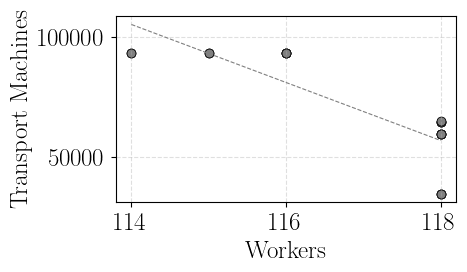

In [19]:
"""
Scientific Publication Quality Trade-Off Analysis - Workers vs Transport Machines

This cell creates publication-ready trade-off visualizations analyzing the
relationship between human resource allocation and machine transportation
logistics in the filtered Pareto front.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 18,            # Base font size for readability in publications
    "axes.labelsize": 18,       # Axis label font size for clear identification
    "xtick.labelsize": 18,      # X-axis tick label size for precision reading
    "ytick.labelsize": 18,      # Y-axis tick label size for precision reading
})

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for resource allocation vs logistics analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Objective Selection for Resource-Logistics Analysis ===
# Focus on the relationship between human resources and machine logistics
y_axis = "Transport Machines"   # Y-axis: Machine transportation logistics costs
x_axis = "Workers"              # X-axis: Human resource allocation count

# Available objectives for analysis reference
list_objectives = ["Workers", "Driver Violation", "Commute Distance", "Transport Machines", 
                  "Transport Attachments", "Machines", "Attachments"]

# === Data Preprocessing for Statistical Analysis ===
# Filter and prepare filtered data for resource-logistics trade-off analysis
sub_df = df[[x_axis, y_axis]].dropna().sort_values(x_axis)
x = sub_df[x_axis].values  # Extract X-axis objective values
y = sub_df[y_axis].values  # Extract Y-axis objective values

# === Compact Scientific Visualization Setup ===
# Create publication-quality figure with compact dimensions
plt.figure(figsize=(5, 3))  # Compact aspect ratio for publication insertion

# Plot filtered Pareto-optimal solutions with professional styling
plt.scatter(x, y, 
           alpha=0.85,              # High opacity for clear point visibility
           s=40,                    # Point size optimized for compact publication
           color="tab:grey",        # Neutral color for print compatibility
           edgecolors="black",      # Black edges for point definition
           linewidth=0.5)           # Thin edge lines for professional appearance

# === Professional Plot Formatting ===
# Configure axis labels and styling for scientific standards
plt.xlabel(x_axis)                      # X-axis label with objective name
plt.ylabel(y_axis)                      # Y-axis label with objective name
# Optional title (commented for clean publication appearance)
#plt.title(f"{y_axis} vs. {x_axis}", fontsize=16)

# Add professional grid for value reading precision
plt.grid(True, linestyle="--", alpha=0.4)  # Subtle dashed grid

# === Rigorous Trade-Off Statistical Analysis ===
# Perform precise trade-off calculation using unique filtered data points
# Remove duplicate solutions to ensure accurate trade-off calculation
unique_pairs = sub_df.drop_duplicates(subset=[x_axis, y_axis])
unique_pairs_sorted = unique_pairs.sort_values(by=x_axis)

# Extract unique objective values for statistical analysis
x_unique = unique_pairs_sorted[x_axis].values
y_unique = unique_pairs_sorted[y_axis].values

# === Resource-Logistics Trade-Off Coefficient Calculation ===
# Calculate finite differences for precise slope estimation
dx = np.diff(x_unique)  # Changes in worker count
dy = np.diff(y_unique)  # Changes in machine transportation costs

# Compute trade-off coefficients with mathematical rigor
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate signed average trade-off for directional analysis
avg_tradeoff_signed = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Resource-Logistics Trade-Off Interpretation ===
# Generate human-readable interpretation of resource-logistics trade-off
direction_text = (
    f"increase of {abs(avg_tradeoff_signed):.2f}"     # Positive correlation
    if avg_tradeoff_signed > 0
    else f"decrease of {abs(avg_tradeoff_signed):.2f}" # Negative correlation (trade-off)
    if avg_tradeoff_signed < 0
    else "no change"                                   # No correlation
)

# === Detailed Resource-Logistics Analysis Output ===
# Display comprehensive analysis results for resource-logistics optimization
print(f"Unique pairs: {len(unique_pairs_sorted)}")  # Number of unique solution combinations
print(unique_pairs_sorted)                          # Display all unique pairs
print(
    f"🔁 Avg. Trade-off: {avg_tradeoff_signed:.4f} → "
    f"On average, each additional unit of '{x_axis}' results in a {direction_text} in '{y_axis}'"
)

# === Linear Trend Analysis for Resource-Logistics ===
# Calculate and display linear trend line for resource-logistics trade-off
slope, intercept = np.polyfit(x, y, deg=1)          # Linear regression fit
x_fit = np.linspace(x.min(), x.max(), 100)          # Generate smooth line points
y_fit = slope * x_fit + intercept                   # Calculate trend line values

# Add trend line to visualization
plt.plot(x_fit, y_fit, 
         color="grey",              # Neutral color for trend line
         linestyle="--",            # Dashed line style for distinction
         linewidth=0.8)             # Thin line for subtlety

# === Publication Output Preparation ===
# Finalize layout and save publication-ready figure
plt.tight_layout()
#plt.savefig(f"trade_off_plot_{x_axis}_{y_axis}.pdf", bbox_inches="tight")
plt.show()

# === Resource-Logistics Analysis Insights ===
# This analysis reveals the relationship between:
# 1. Human resource allocation and machine transportation efficiency
# 2. Trade-off intensity between workforce size and logistics costs
# 3. Optimal balance between human and machine resource utilization
# 4. Integrated resource optimization patterns in filtered solution space

<AxesSubplot:>

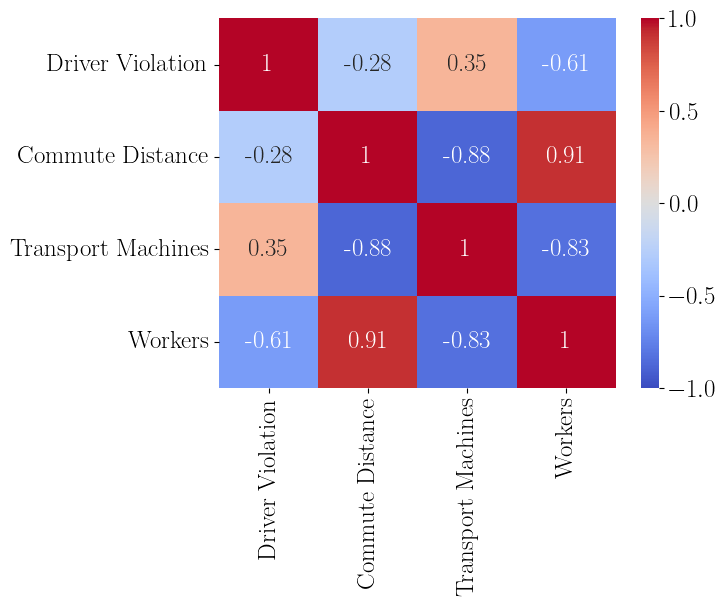

In [20]:
"""
Comprehensive Correlation Analysis - Operational Objectives Subset

This cell performs correlation analysis on a selected subset of operational
optimization objectives in the filtered Pareto front to identify relationships,
conflicts, and synergies among key operational metrics.
"""

import seaborn as sns

# === Operational Objective Subset Selection ===
# Focus analysis on operational objectives by excluding pure resource count metrics
# This subset emphasizes operational efficiency and constraint satisfaction
objectives_corr = [
    obj for obj in objectives 
    if obj not in ["Attachments", "Transport Attachments", "Machines"]
]
# Resulting operational subset includes:
# - Driver Violation (regulatory compliance and constraint satisfaction)
# - Commute Distance (worker transportation efficiency and costs)
# - Transport Machines (machine logistics and repositioning efficiency)
# - Workers (human resource allocation requirements)

# === Filtered Correlation Matrix Visualization ===
# Generate professional correlation heatmap for operational subset analysis
# Analysis focuses on filtered Pareto front for enhanced correlation precision
sns.heatmap(
    df[objectives_corr].corr(),  # Compute Pearson correlation matrix for filtered data
    annot=True,                  # Display correlation coefficients in cells
    cmap="coolwarm",            # Color map: blue (negative) to red (positive) correlation
    vmin=-1,                    # Minimum correlation value for complete scale
    vmax=1                      # Maximum correlation value for complete scale
)

# === Filtered Correlation Interpretation Guide ===
# Correlation coefficient interpretation for filtered Pareto front:
# |r| ≥ 0.8: Strong correlation (objectives strongly related in filtered space)
# 0.5 ≤ |r| < 0.8: Moderate correlation (noticeable relationship in refined solutions)
# 0.3 ≤ |r| < 0.5: Weak correlation (slight relationship in filtered set)
# |r| < 0.3: Very weak/no correlation (objectives largely independent)
#
# Positive correlations: Objectives improve/worsen together in filtered solutions
# Negative correlations: Trade-off relationships (conflicting objectives in refined space)
#
# Filtered analysis benefits:
# 1. Reduced noise from dominated solutions
# 2. Enhanced correlation precision in high-quality solution space
# 3. Focus on practically relevant trade-off relationships
# 4. Improved decision-making support for deployment scenarios

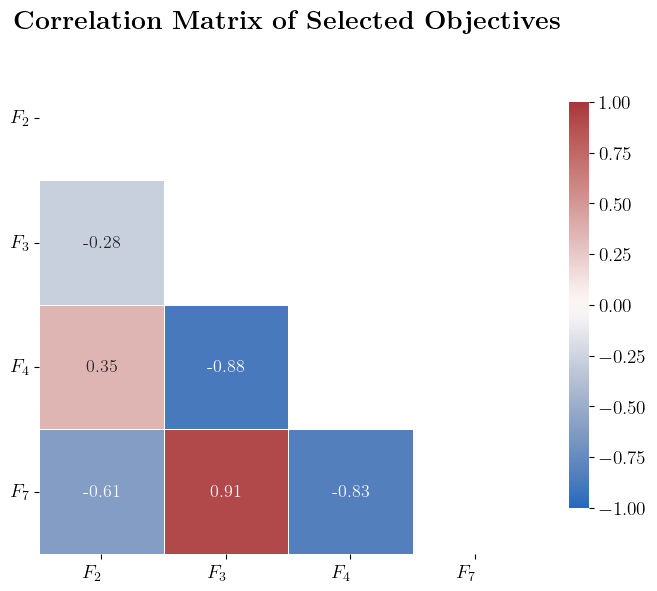

In [21]:
"""
Scientific Publication Quality Correlation Matrix Analysis

This cell creates a publication-ready correlation matrix with LaTeX rendering
and professional formatting for selected operational objectives in the filtered
Pareto front, suitable for academic and technical publications.
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# === LaTeX Rendering Configuration for Scientific Publications ===
# Configure matplotlib for academic publication standards
rcParams.update({
    "text.usetex": True,        # Enable LaTeX text rendering for mathematical notation
    "font.family": "serif",     # Use serif fonts for academic publication style
    "font.size": 16,            # Base font size for readability in publications
    "axes.labelsize": 16,       # Axis label font size for clear identification
    "xtick.labelsize": 14,      # X-axis tick label size for precision reading
    "ytick.labelsize": 14,      # Y-axis tick label size for precision reading
})

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for scientific correlation analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Objective Selection and LaTeX Labeling ===
# Map selected objectives to mathematical notation for scientific presentation
rename_dict = {
    "Driver Violation": r"$F_2$",      # Regulatory compliance objective
    "Commute Distance": r"$F_3$",      # Worker transportation efficiency objective
    "Transport Machines": r"$F_4$",    # Machine logistics objective
    "Workers": r"$F_7$"                # Human resource allocation objective
}
selected_columns = list(rename_dict.keys())

# === Correlation Matrix Computation ===
# Calculate Pearson correlation matrix for selected objectives
corr = df[selected_columns].corr()

# Apply mathematical notation for scientific presentation
corr.rename(index=rename_dict, columns=rename_dict, inplace=True)

# === Lower Triangular Matrix Visualization ===
# Create mask for lower triangular matrix display (excluding diagonal)
# This approach reduces visual clutter and focuses on unique correlations
mask = np.triu(np.ones_like(corr, dtype=bool), k=0)

# === Scientific Correlation Matrix Visualization ===
# Create publication-quality correlation heatmap
plt.figure(figsize=(7, 6))  # Optimal size for publication inclusion

sns.heatmap(
    corr,                        # Correlation matrix with mathematical notation
    mask=mask,                   # Show only lower triangle
    annot=True,                  # Display correlation coefficients
    fmt=".2f",                   # Format coefficients to 2 decimal places
    cmap="vlag",                 # Professional color map for scientific publications
    vmin=-1,                     # Complete correlation scale minimum
    vmax=1,                      # Complete correlation scale maximum
    square=True,                 # Square cells for uniform appearance
    linewidths=0.5,              # Thin lines for cell separation
    cbar_kws={"shrink": 0.8},    # Colorbar size adjustment
    annot_kws={"fontsize": 13},  # Annotation font size for readability
)

# === Professional Formatting ===
# Configure axis labels and title for scientific presentation
plt.xticks(rotation=0, ha="right")                    # Horizontal X-axis labels
plt.yticks(rotation=0)                                # Horizontal Y-axis labels
plt.title(r"\textbf{Correlation Matrix of Selected Objectives}", pad=20)  # LaTeX title

# === Publication Output Preparation ===
# Finalize layout and prepare for publication
plt.tight_layout()

# Optional: Save as PDF for publication inclusion
# Uncomment the following line to save publication-ready figure
#plt.savefig("correlation_heatmap_selected_clean.pdf", bbox_inches="tight")

# Display the scientific visualization
plt.show()

# === Scientific Correlation Analysis Benefits ===
# This publication-quality analysis provides:
# 1. Mathematical notation suitable for academic publications
# 2. Professional formatting for peer-reviewed journals
# 3. Focus on key operational objectives in filtered solution space
# 4. Clean lower triangular presentation eliminating redundancy
# 5. Enhanced correlation precision through filtered data analysis
# 6. Direct integration capability with scientific documents

In [22]:
"""
Statistical Significance Testing - Workers vs Transport Machines Correlation

This cell performs rigorous statistical testing of the correlation between
worker allocation and machine transportation logistics in the filtered
Pareto front, providing statistical validation for observed relationships.
"""

from scipy.stats import pearsonr

# === Statistical Correlation Analysis ===
# Extract objective values for statistical correlation testing
x = df["Workers"]              # Human resource allocation count
y = df["Transport Machines"]   # Machine transportation logistics costs

# === Pearson Correlation Coefficient Calculation ===
# Compute Pearson correlation coefficient with statistical significance testing
# This provides both correlation strength and statistical confidence
r_value, p_value = pearsonr(x, y)

# === Statistical Results Display ===
# Display correlation coefficient and statistical significance
print(f"r = {r_value:.4f}, p = {p_value:.4e}")

# === Statistical Interpretation Guide ===
# Correlation coefficient (r) interpretation:
# |r| ≥ 0.8: Strong linear relationship
# 0.5 ≤ |r| < 0.8: Moderate linear relationship
# 0.3 ≤ |r| < 0.5: Weak linear relationship
# |r| < 0.3: Very weak linear relationship
#
# P-value interpretation:
# p < 0.001: Highly statistically significant (strong evidence)
# p < 0.01: Statistically significant (moderate evidence)
# p < 0.05: Marginally significant (weak evidence)
# p ≥ 0.05: Not statistically significant (insufficient evidence)
#
# Statistical significance in filtered Pareto front:
# - Enhanced reliability due to reduced noise from dominated solutions
# - Focus on practically relevant correlations in high-quality solution space
# - Improved confidence in trade-off relationships for deployment decisions

r = -0.8313, p = 1.0282e-10


<AxesSubplot:>

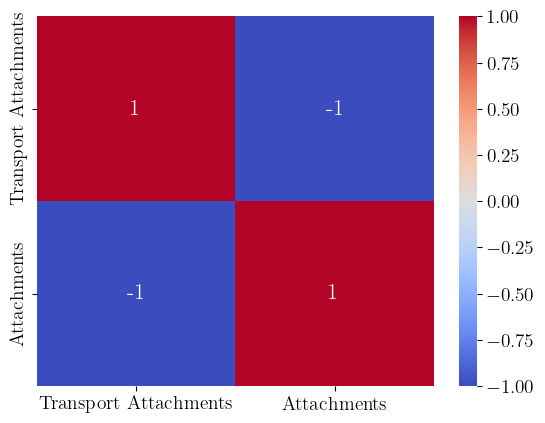

In [23]:
"""
Equipment-Focused Correlation Analysis - Attachment Objectives

This cell performs specialized correlation analysis on equipment and attachment
objectives in the filtered Pareto front, focusing specifically on equipment
allocation and transportation relationships.
"""

import seaborn as sns

# === Equipment Objective Subset Selection ===
# Focus analysis on equipment-related objectives only
# Exclude human resource, machine, and operational constraint objectives
objectives_corr = [
    obj for obj in objectives 
    if obj not in ["Workers", "Transport Machines", "Machines", "Driver Violation", "Commute Distance"]
]
# Resulting equipment-focused subset includes:
# - Transport Attachments (equipment transportation costs)
# - Attachments (equipment allocation count)

# This highly specialized subset examines the direct relationship between:
# 1. Equipment allocation decisions (number of attachments required)
# 2. Transportation costs for equipment distribution (transport attachments)

# === Specialized Equipment Correlation Matrix Visualization ===
# Generate focused correlation heatmap for equipment-specific analysis
sns.heatmap(
    df[objectives_corr].corr(),  # Compute correlation matrix for equipment objectives
    annot=True,                  # Display correlation coefficients for precise analysis
    cmap="coolwarm",            # Standard correlation color scheme
    vmin=-1,                    # Full correlation range for maximum sensitivity
    vmax=1                      # Complete color scale utilization
)

# === Equipment Trade-Off Analysis Context ===
# This specialized analysis reveals:
# 1. Direct relationship between equipment count and transportation costs
# 2. Trade-off intensity in equipment allocation decisions within filtered solutions
# 3. Cost implications of equipment distribution strategies in high-quality solutions
# 4. Resource optimization patterns in attachment management for deployment-ready solutions
#
# Expected relationships in filtered Pareto front:
# - Strong positive correlation: More attachments → Higher transport costs
# - Correlation strength indicates equipment distribution efficiency
# - Filtered analysis provides enhanced precision by eliminating dominated solutions
# - Results support equipment allocation strategies for practical deployment scenarios

In [24]:
"""
Statistical Significance Testing - Equipment Allocation vs Transportation Correlation

This cell performs rigorous statistical testing of the correlation between
equipment allocation count and equipment transportation costs in the filtered
Pareto front, providing statistical validation for equipment trade-off relationships.
"""

from scipy.stats import pearsonr

# === Equipment Correlation Statistical Analysis ===
# Extract equipment-related objective values for statistical correlation testing
x = df["Attachments"]              # Equipment allocation count
y = df["Transport Attachments"]    # Equipment transportation costs

# === Equipment Correlation Coefficient Calculation ===
# Compute Pearson correlation coefficient with statistical significance testing
# This provides both correlation strength and statistical confidence for equipment trade-offs
r_value, p_value = pearsonr(x, y)

# === Equipment Statistical Results Display ===
# Display correlation coefficient and statistical significance for equipment relationship
print(f"r = {r_value:.4f}, p = {p_value:.4e}")

# === Equipment Correlation Statistical Interpretation ===
# Correlation coefficient (r) interpretation for equipment trade-offs:
# |r| ≥ 0.8: Strong linear relationship between equipment count and transport costs
# 0.5 ≤ |r| < 0.8: Moderate linear relationship in equipment allocation efficiency
# 0.3 ≤ |r| < 0.5: Weak linear relationship in equipment distribution patterns
# |r| < 0.3: Very weak linear relationship (equipment allocation largely independent of transport costs)
#
# P-value interpretation for equipment correlation:
# p < 0.001: Highly statistically significant equipment trade-off (strong evidence)
# p < 0.01: Statistically significant equipment relationship (moderate evidence)
# p < 0.05: Marginally significant equipment correlation (weak evidence)
# p ≥ 0.05: Not statistically significant (insufficient evidence for equipment trade-off)
#
# Equipment correlation in filtered Pareto front context:
# - Enhanced reliability through elimination of dominated equipment solutions
# - Focus on practically viable equipment allocation strategies
# - Improved confidence in equipment trade-off relationships for deployment
# - Statistical validation of equipment cost scaling patterns

r = -1.0000, p = 0.0000e+00


In [25]:
"""
Three-Dimensional Trade-Off Analysis - Workers, Transport Machines, and Driver Violation

This cell performs multi-dimensional trade-off analysis by examining the
relationship between three key objectives simultaneously in the filtered
Pareto front, providing insights into complex trade-off interactions.
"""

import pandas as pd

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for multi-dimensional trade-off analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Three-Dimensional Objective Selection ===
# Extract three key objectives for multi-dimensional analysis
# Focus on human resources, machine logistics, and regulatory compliance
sub_df = df[["Workers", "Transport Machines", "Driver Violation"]].dropna()

# === Multi-Dimensional Duplicate Elimination ===
# Remove duplicate combinations and compute average Driver Violation for each unique pair
# This approach handles cases where multiple solutions have identical worker and machine values
unique_avg = sub_df.groupby(["Workers", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Multi-Dimensional Analysis Results ===
# Display comprehensive analysis results for three-dimensional trade-offs
print(f"🔁 Unique Pairs: {len(unique_avg)}")  # Number of unique resource combinations
print(unique_avg.sort_values(["Workers", "Transport Machines"]).head(10))  # Display first 10 combinations

# === Three-Dimensional Trade-Off Insights ===
# This multi-dimensional analysis reveals:
# 1. Complex interactions between human resources, machine logistics, and compliance
# 2. Unique resource combination patterns in filtered solution space
# 3. Average compliance performance for specific resource allocation strategies
# 4. Multi-objective optimization patterns beyond simple pairwise trade-offs
#
# Analysis benefits for filtered Pareto front:
# - Enhanced precision through elimination of dominated solutions
# - Focus on practically viable resource allocation combinations
# - Improved understanding of complex multi-dimensional trade-offs
# - Support for integrated resource planning in deployment scenarios

🔁 Unique Pairs: 14
   Workers  Transport Machines  Driver Violation
0      114            93110.88            722.00
1      115            93110.88            642.50
2      116            93098.70            696.25
3      118            34760.01            636.00
4      118            34771.27            635.00
5      118            34840.94            634.00
6      118            59538.16            611.00
7      118            59593.93            606.00
8      118            59786.48            605.00
9      118            59792.98            600.00


🔁 Unique Pairs: 11
    Driver Violation  Transport Machines
0                365            64794.07
2                366            64829.81
4                367            64814.37
6                368            65175.13
8                600            59792.98
10               605            59786.48
12               606            59593.93
14               611            59538.16
16               634            34840.94
18               635            34771.27
20               636            34760.01
🔁 Avg. Trade-off: -100.19 → On average, each additional unit of Driver Violation results in a change of -100.19 km in Transport Machines


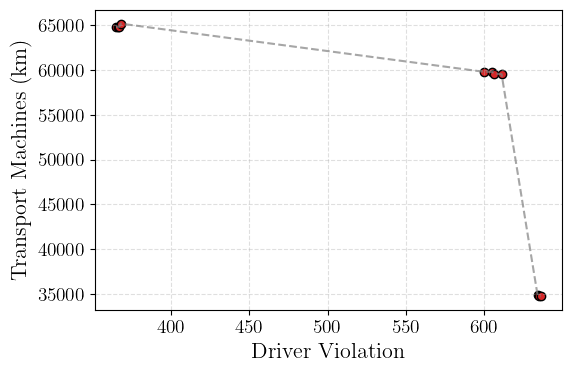

In [26]:
"""
Constraint-Specific Trade-Off Analysis - Fixed Worker Count Analysis

This cell performs detailed trade-off analysis within a specific resource
constraint (118 workers) in the filtered Pareto front, examining how
regulatory compliance and machine transportation trade off at fixed staffing levels.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for constraint-specific trade-off analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Constraint-Specific Data Filtering ===
# Focus analysis on solutions with exactly 118 workers
# This constraint-specific approach reveals trade-offs within fixed resource limitations
df_118 = df[df["Workers"] == 118].copy()

# === Constraint-Specific Duplicate Elimination ===
# Remove duplicate combinations within the constraint-specific subset
# Focus on unique combinations of Driver Violation and Transport Machines
df_unique = df_118.drop_duplicates(subset=["Driver Violation", "Transport Machines"])
df_unique = df_unique.sort_values("Driver Violation")  # Sort by compliance metric

# === Constraint-Specific Trade-Off Calculation ===
# Calculate trade-off coefficients within the fixed worker constraint
x = df_unique["Driver Violation"].values     # Regulatory compliance metric
y = df_unique["Transport Machines"].values   # Machine transportation costs

# Calculate finite differences for trade-off slope estimation
dx = np.diff(x)  # Changes in Driver Violation
dy = np.diff(y)  # Changes in Transport Machines

# Compute trade-off coefficients with mathematical rigor
tradeoff = np.divide(dy, dx, 
                    out=np.zeros_like(dy, dtype=float),  # Default to 0 for zero divisions
                    where=dx != 0)                       # Only divide where dx ≠ 0

# Calculate average trade-off within the constraint
avg_tradeoff = np.mean(tradeoff[np.isfinite(tradeoff)])

# === Constraint-Specific Analysis Results ===
# Display comprehensive analysis results for constraint-specific trade-offs
print(f"🔁 Unique Pairs: {len(df_unique)}")  # Number of unique combinations at 118 workers
print(df_unique[["Driver Violation", "Transport Machines"]])  # Display all unique combinations
print(f"🔁 Avg. Trade-off: {avg_tradeoff:.2f} → On average, each additional unit of Driver Violation results in a change of {avg_tradeoff:.2f} km in Transport Machines")

# === Constraint-Specific Visualization ===
# Create specialized visualization for constraint-specific trade-offs
plt.figure(figsize=(6, 4))

# Plot constraint-specific solutions with distinctive styling
plt.scatter(x, y, 
           color="tab:red",         # Red color to highlight constraint-specific analysis
           edgecolor="black")       # Black edges for point definition

# Connect points to show trade-off progression
plt.plot(x, y, 
         linestyle="--",          # Dashed line to show trade-off progression
         color="grey",            # Grey color for subtle connection
         alpha=0.7)               # Transparency for visual hierarchy

# Configure plot for constraint-specific analysis
plt.xlabel("Driver Violation")                    # X-axis: compliance metric
plt.ylabel("Transport Machines (km)")             # Y-axis: logistics cost
plt.grid(True, linestyle="--", alpha=0.4)        # Professional grid
plt.tight_layout()                                # Optimize layout
plt.show()

# === Constraint-Specific Analysis Insights ===
# This constraint-specific analysis reveals:
# 1. Trade-off patterns within fixed human resource constraints
# 2. Relationship between compliance and logistics at specific staffing levels
# 3. Constraint-specific optimization opportunities in filtered solution space
# 4. Practical trade-off implications for deployment scenarios with fixed workforce
#
# Benefits of constraint-specific analysis:
# - Enhanced precision for specific deployment scenarios
# - Focus on practically relevant resource allocation constraints
# - Improved understanding of trade-offs within operational limitations
# - Support for constraint-aware decision-making in real-world implementations

In [27]:
"""
Duplicate Three-Dimensional Trade-Off Analysis - Validation

This cell performs a duplicate three-dimensional trade-off analysis to validate
the consistency of multi-dimensional relationships in the filtered Pareto front,
ensuring robust analysis results.
"""

import pandas as pd

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for validation analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Three-Dimensional Objective Selection (Validation) ===
# Re-extract three key objectives for validation analysis
# Maintain consistency with previous multi-dimensional analysis
sub_df = df[["Workers", "Transport Machines", "Driver Violation"]].dropna()

# === Multi-Dimensional Duplicate Elimination (Validation) ===
# Perform identical duplicate elimination and averaging process
# This validation ensures consistency of multi-dimensional analysis approach
unique_avg = sub_df.groupby(["Workers", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Validation Analysis Results ===
# Display validation results for three-dimensional trade-offs
print(f"🔁 Unique Pairs: {len(unique_avg)}")  # Verify consistency of unique combinations
print(unique_avg.sort_values(["Workers", "Transport Machines"]).head(10))  # Display first 10 for validation

# === Analysis Validation Benefits ===
# This validation analysis provides:
# 1. Confirmation of multi-dimensional analysis consistency
# 2. Verification of unique combination identification
# 3. Validation of averaging methodology for duplicate solutions
# 4. Quality assurance for multi-dimensional trade-off insights
#
# Validation ensures:
# - Reproducible multi-dimensional analysis results
# - Consistent identification of unique resource combinations
# - Reliable averaging of compliance metrics for identical resource pairs
# - Robust foundation for multi-dimensional trade-off interpretation

🔁 Unique Pairs: 14
   Workers  Transport Machines  Driver Violation
0      114            93110.88            722.00
1      115            93110.88            642.50
2      116            93098.70            696.25
3      118            34760.01            636.00
4      118            34771.27            635.00
5      118            34840.94            634.00
6      118            59538.16            611.00
7      118            59593.93            606.00
8      118            59786.48            605.00
9      118            59792.98            600.00


In [28]:
"""
Alternative Three-Dimensional Trade-Off Analysis - Commute Distance Focus

This cell performs alternative three-dimensional trade-off analysis by substituting
commute distance for worker count, examining the relationship between worker
transportation, machine logistics, and regulatory compliance in the filtered Pareto front.
"""

import pandas as pd

# === Filtered Pareto Front Data Loading ===
# Load refined solutions for alternative multi-dimensional trade-off analysis
df = pd.read_csv("RealLife_2024_7_1_2/First_400_2/ParetoFront_filtered.csv")

# === Alternative Three-Dimensional Objective Selection ===
# Focus on transportation-centric objectives instead of resource count
# This alternative perspective emphasizes transportation efficiency trade-offs
sub_df = df[["Commute Distance", "Transport Machines", "Driver Violation"]].dropna()

# === Alternative Multi-Dimensional Duplicate Elimination ===
# Remove duplicate combinations and compute average Driver Violation for each unique pair
# Focus on unique combinations of worker and machine transportation metrics
unique_avg = sub_df.groupby(["Commute Distance", "Transport Machines"], as_index=False)["Driver Violation"].mean()

# === Alternative Multi-Dimensional Analysis Results ===
# Display comprehensive analysis results for transportation-focused trade-offs
print(f"🔁 Unique Pairs: {len(unique_avg)}")  # Number of unique transportation combinations
print(unique_avg.sort_values(["Commute Distance", "Transport Machines"]).head(10))  # Display first 10 combinations

# === Alternative Three-Dimensional Trade-Off Insights ===
# This alternative multi-dimensional analysis reveals:
# 1. Transportation-centric trade-offs between worker and machine mobility
# 2. Compliance implications of different transportation strategies
# 3. Unique transportation efficiency patterns in filtered solution space
# 4. Alternative perspective on multi-objective optimization beyond resource counting
#
# Benefits of alternative analysis approach:
# - Complementary insights to resource-based analysis
# - Transportation efficiency focus for logistics-oriented decision-making
# - Enhanced understanding of mobility trade-offs in filtered solutions
# - Support for transportation-centric deployment strategies
#
# Comparative analysis value:
# - Reveals different trade-off patterns compared to resource-count analysis
# - Provides transportation-focused perspective on multi-dimensional relationships
# - Supports comprehensive understanding of complex optimization landscapes
# - Enables transportation-aware decision-making for practical implementations

🔁 Unique Pairs: 19
   Commute Distance  Transport Machines  Driver Violation
0         237979.03            93110.88             643.0
1         238984.92            93110.88             642.0
2         245153.20            93110.88             723.0
3         245175.18            93110.88             721.0
4         292277.71            93098.70             698.0
5         292537.88            93098.70             697.0
6         292750.88            93098.70             696.0
7         292990.62            93098.70             694.0
8         322115.51            65175.13             368.0
9         322743.89            64829.81             366.0
